# Diameter distribution

## Foreword
Diameter distribution analysis is the fundamental diagnostic tool for sustainable forest management (SFM) in the tropics, acting as a structural "census" that evaluates demographic health and regenerative potential. In stable, uneven-aged tropical ecosystems, this analysis typically reveals an "inverse J-shaped" curve, where a high density of small-diameter recruits ensures the future replacement of the fewer, larger canopy trees that dominate carbon stocks and biomass (Kohyama, 1993; West *et al.*, 2009). By quantifying these size classes, managers can calculate the q-ratio to identify structural gaps—such as a lack of mid-sized trees—which often indicate historical over-exploitation, intense competition, or recruitment failure (Lamprecht, 1990). This structural data is critical for determining Annual Allowable Cut (AAC) quotas, ensuring that timber extraction does not exceed the forest's natural growth rate, and for protecting "large-stature" trees that Feldpausch *et al.* (2012) demonstrated are disproportionately responsible for above-ground carbon storage. Ultimately, monitoring these distributions under a Reduced Impact Logging (RIL) framework allows for the maintenance of a forest's functional resilience, biodiversity, and long-term economic viability (Putz *et al.*, 2008).

Here we present a diameter distribution analysis made for Yurumanguí's forests as a tools for assessing stand density in tropical forests based on tree thickness.

## 1. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from inventory_data import load_inventory

## 2. Data import

In [37]:
# Load an Excel file
df = df = load_inventory()

## 3. Data tidy

In [38]:
#The of each line in hectares
plot_size = 5000
plot_size_ha = plot_size/10000

print(f'The area of sample plots is: {plot_size} m², which means {plot_size_ha} ha.')

# counts per line
plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()
print(plot_counts)

The area of sample plots is: 5000 m², which means 0.5 ha.
Line Number
1    12
2    19
3    18
4     7
5    10
6    12
7    11
Name: Plot, dtype: int64


C:\Users\migue\AppData\Local\Temp\ipykernel_14052\4092700538.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()


In [39]:
line_area_df = plot_counts.rename('plot_count').to_frame().assign(line_area_ha=lambda x: x['plot_count'] * plot_size_ha)
print(line_area_df)

             plot_count  line_area_ha
Line Number                          
1                    12           6.0
2                    19           9.5
3                    18           9.0
4                     7           3.5
5                    10           5.0
6                    12           6.0
7                    11           5.5


## 4. Diameter distribution

| Diameter class      | Class interval [cm] |
|:-------------------:|:-------------------:|
| I                   | 10-20               |
| II                  | 20-30               |
| III                 | 30-40               |
| IV                  | 40-50               |
| V                   | 50-60               |
| VI                  | 60-70               |
| VII                 | 70-80               |
| VIII                |80-90                |
| IX                  |90-100               |
| X                   |100-110              |
| XI                  |110-120              |
| XII                 |120-130              |
| XIII                |130-140              |
| XIV                 |140-150              |
| XV                  |150-160              |
| XVI                 |160-170              |
| XVII                |170-180              |
| XVIII               |180-190              |
| XIX                 |190-200              |
| XX                  |> 200                |

### 4.1 Diameter distribution along lines

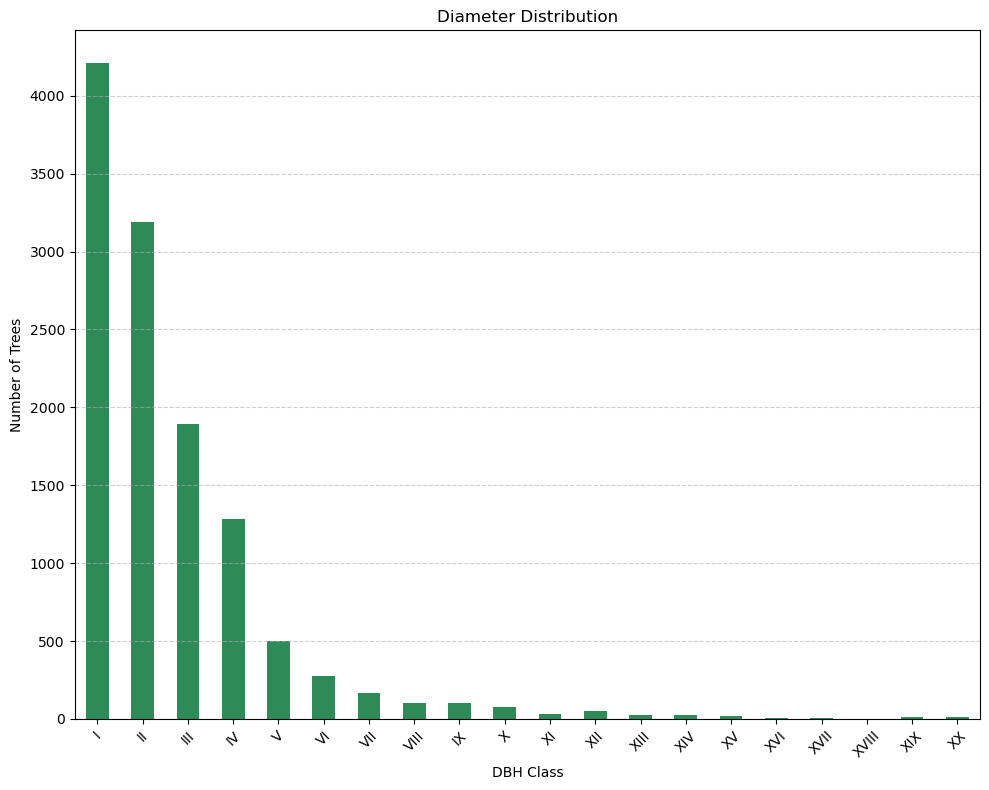

In [40]:
#Let's plot the diameter distribution
plt.figure(figsize=(10,8))
df["DBH Class"].value_counts().sort_index().plot(kind='bar', color='#2E8B57')
plt.xlabel('DBH Class')
plt.ylabel('Number of Trees')
plt.title('Diameter Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

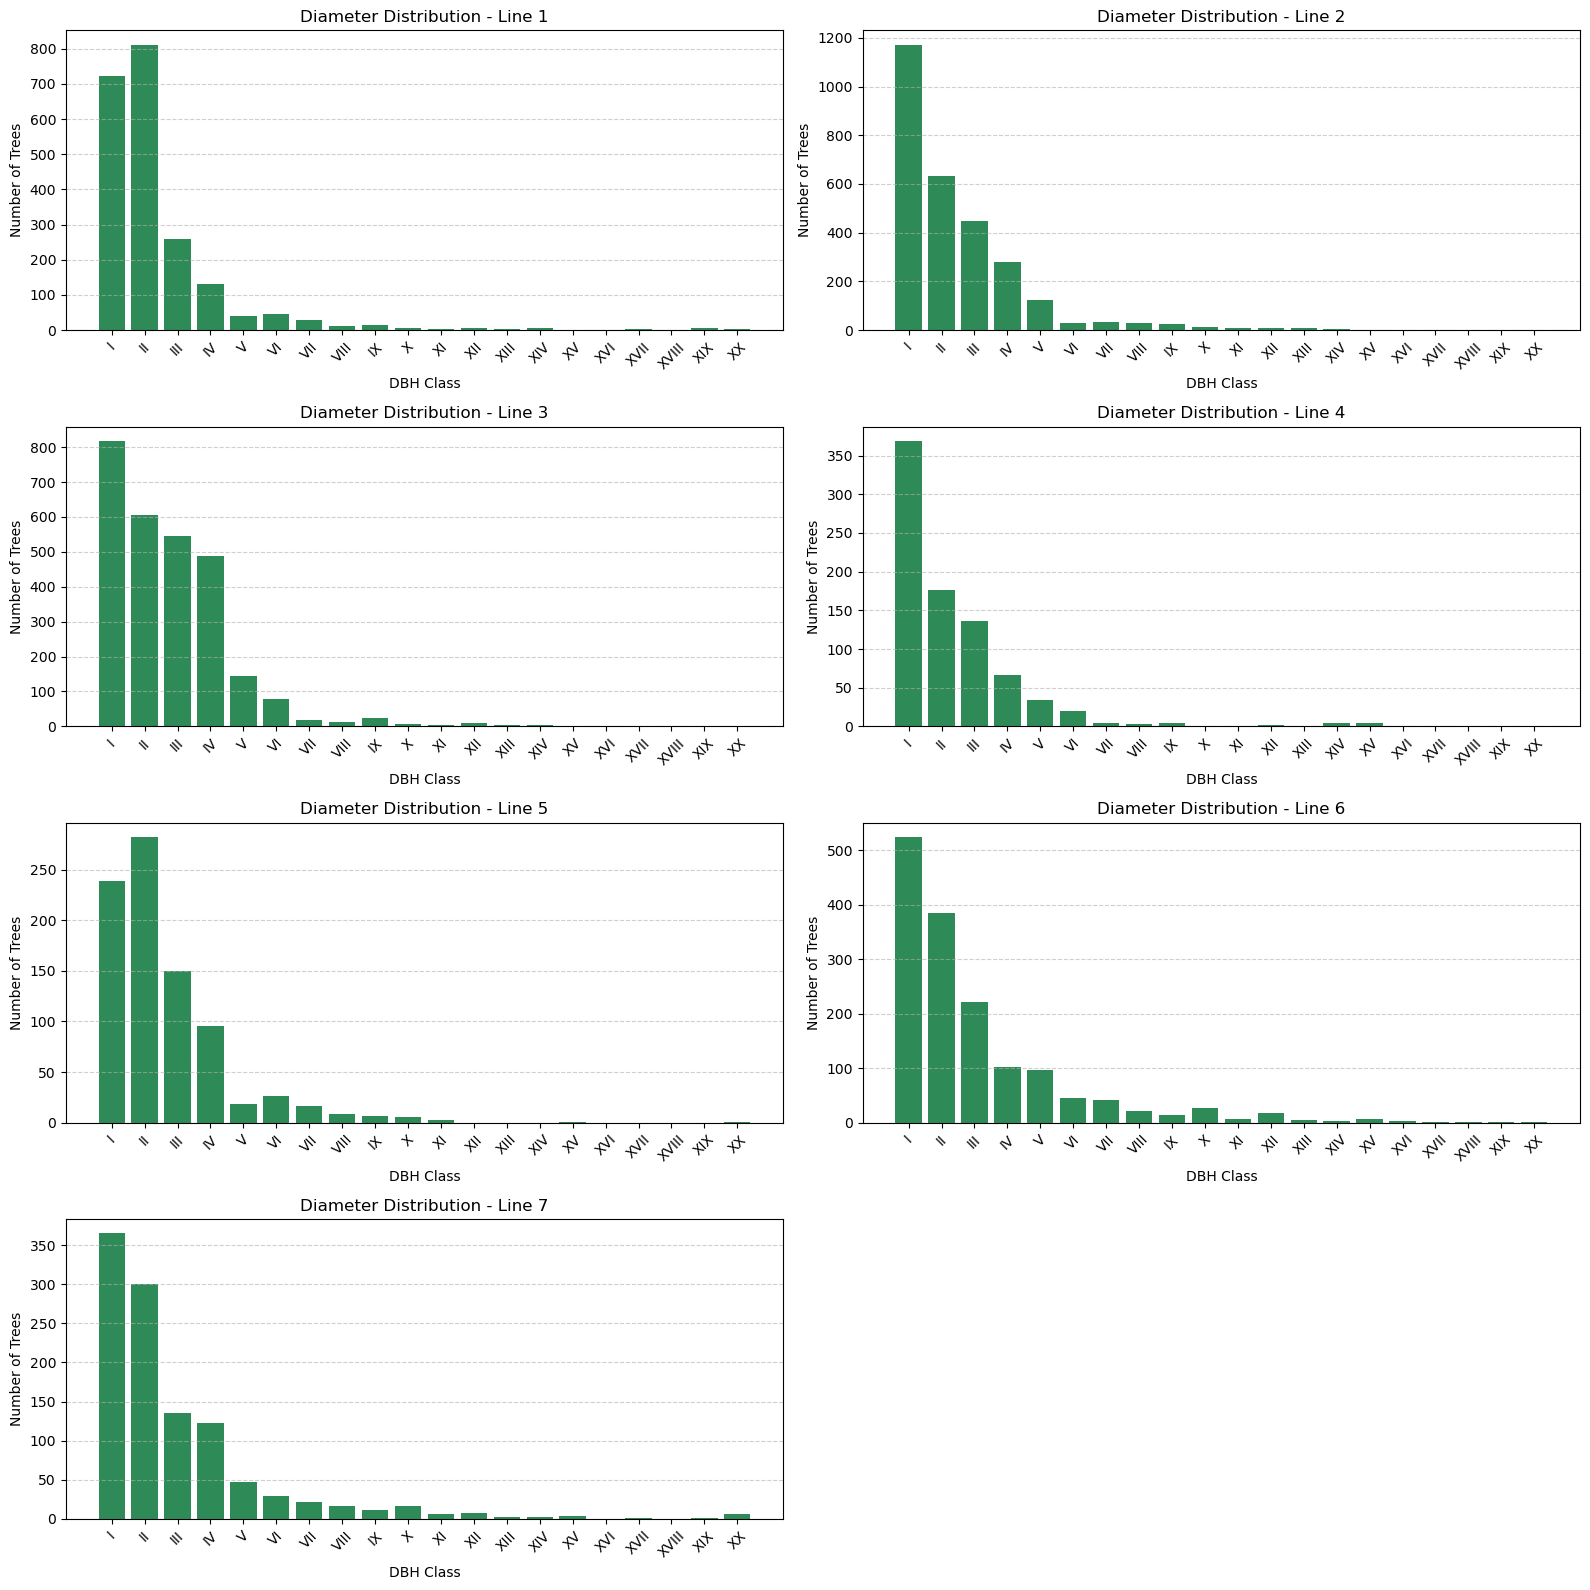

In [41]:
# Create a 4x2 matrix of subplots, one for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    dbh_class_counts = line_data["DBH Class"].value_counts().sort_index()
    
    axes[i].bar(range(len(dbh_class_counts)), dbh_class_counts.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees')
    axes[i].set_title(f'Diameter Distribution - Line {line_num}')
    axes[i].set_xticks(range(len(dbh_class_counts)))
    axes[i].set_xticklabels(dbh_class_counts.index, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_14052\3604199684.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()


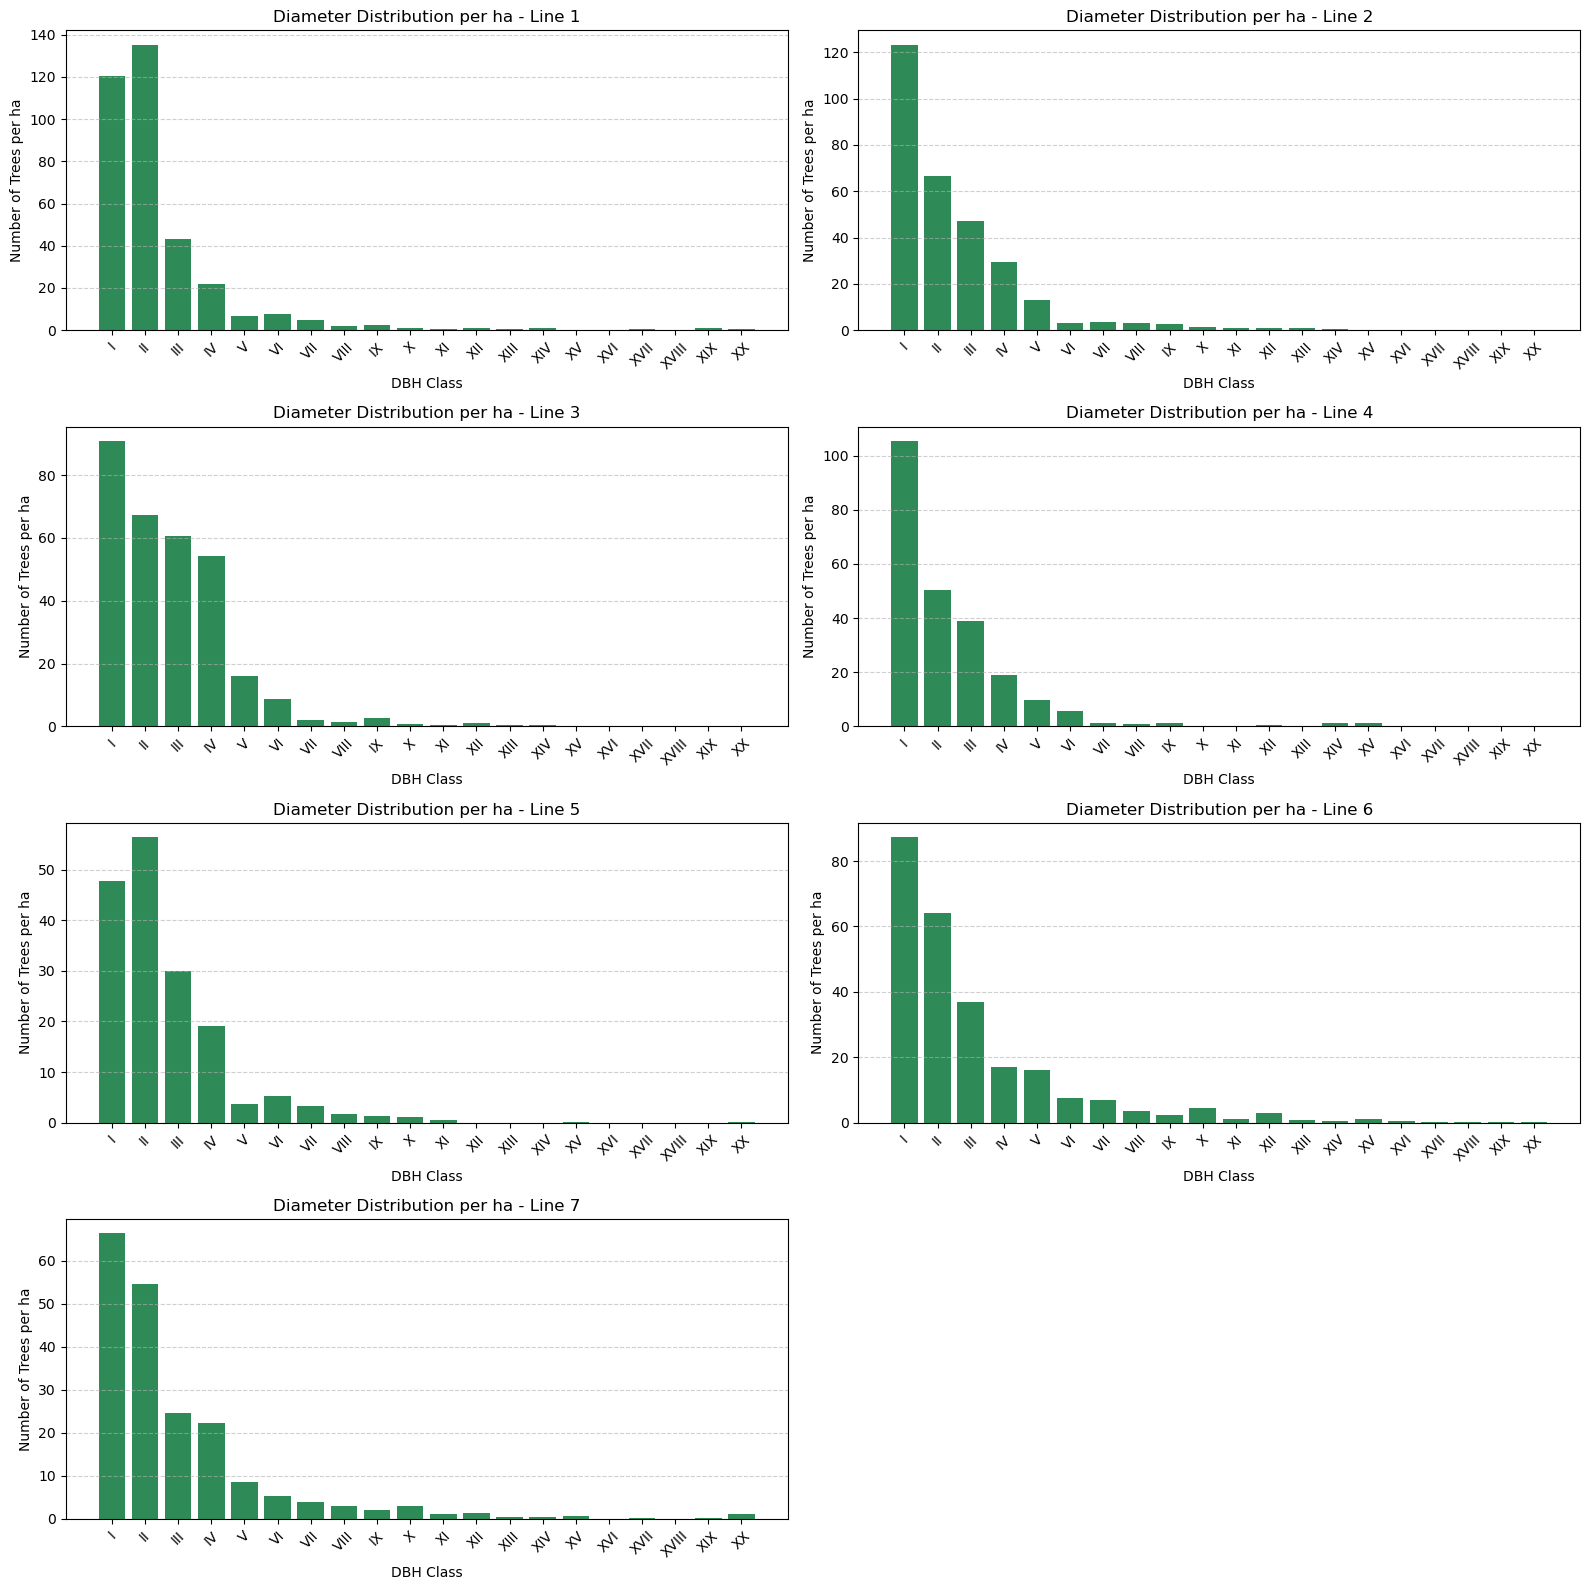

In [42]:
# Create a 4x2 matrix of subplots, one for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    dbh_class_counts = line_data["DBH Class"].value_counts().sort_index()

    # Compute per-hectare counts (handle missing/zero area)
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        dbh_per_ha = dbh_class_counts / area
    else:
        # if area is missing or zero, set NaN to avoid division by zero
        dbh_per_ha = pd.Series([np.nan] * len(dbh_class_counts), index=dbh_class_counts.index)

    axes[i].bar(range(len(dbh_per_ha)), dbh_per_ha.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees per ha')
    axes[i].set_title(f'Diameter Distribution per ha - Line {line_num}')
    axes[i].set_xticks(range(len(dbh_per_ha)))
    axes[i].set_xticklabels(dbh_per_ha.index, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\migue\AppData\Local\Temp\ipykernel_14052\2641003323.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Line Number')['DBH [cm]']
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\2641003323.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(x=[group.values for name, group in grouped],


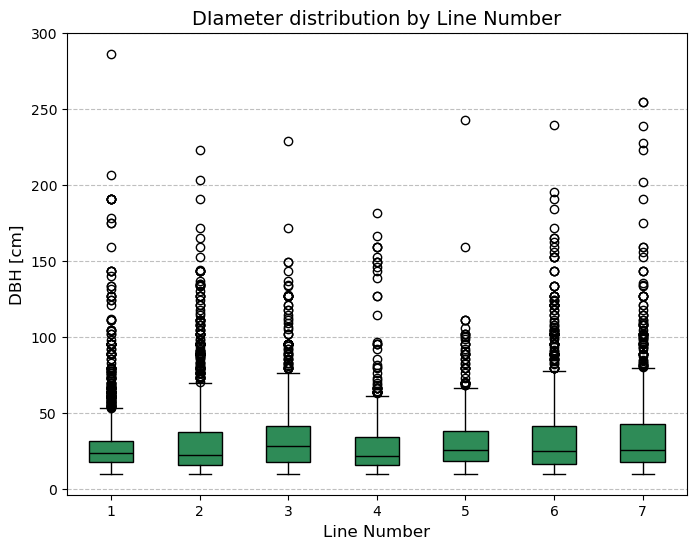

In [43]:
# Group our dataset with our 'Group' variable
grouped = df.groupby('Line Number')['DBH [cm]']

# Init a figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Create the plot with different colors for each group
boxplot = ax.boxplot(x=[group.values for name, group in grouped],
                     labels=grouped.groups.keys(),
                     patch_artist=True,
                     medianprops={'color': 'black'}
                    )

# Assign colors to each box in the boxplot
for box, color in zip(boxplot['boxes'], ['#2E8B57'] * len(boxplot['boxes'])):
    box.set_facecolor(color)
    
# Add a title and axis label
ax.set_title('DIameter distribution by Line Number', fontsize=14)

ax.set_xlabel('Line Number', fontsize=12)
ax.set_ylabel('DBH [cm]', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.8)
# Display it
plt.show()

### 4.2 Basal area

C:\Users\migue\AppData\Local\Temp\ipykernel_14052\3726085115.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\3726085115.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\3726085115.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

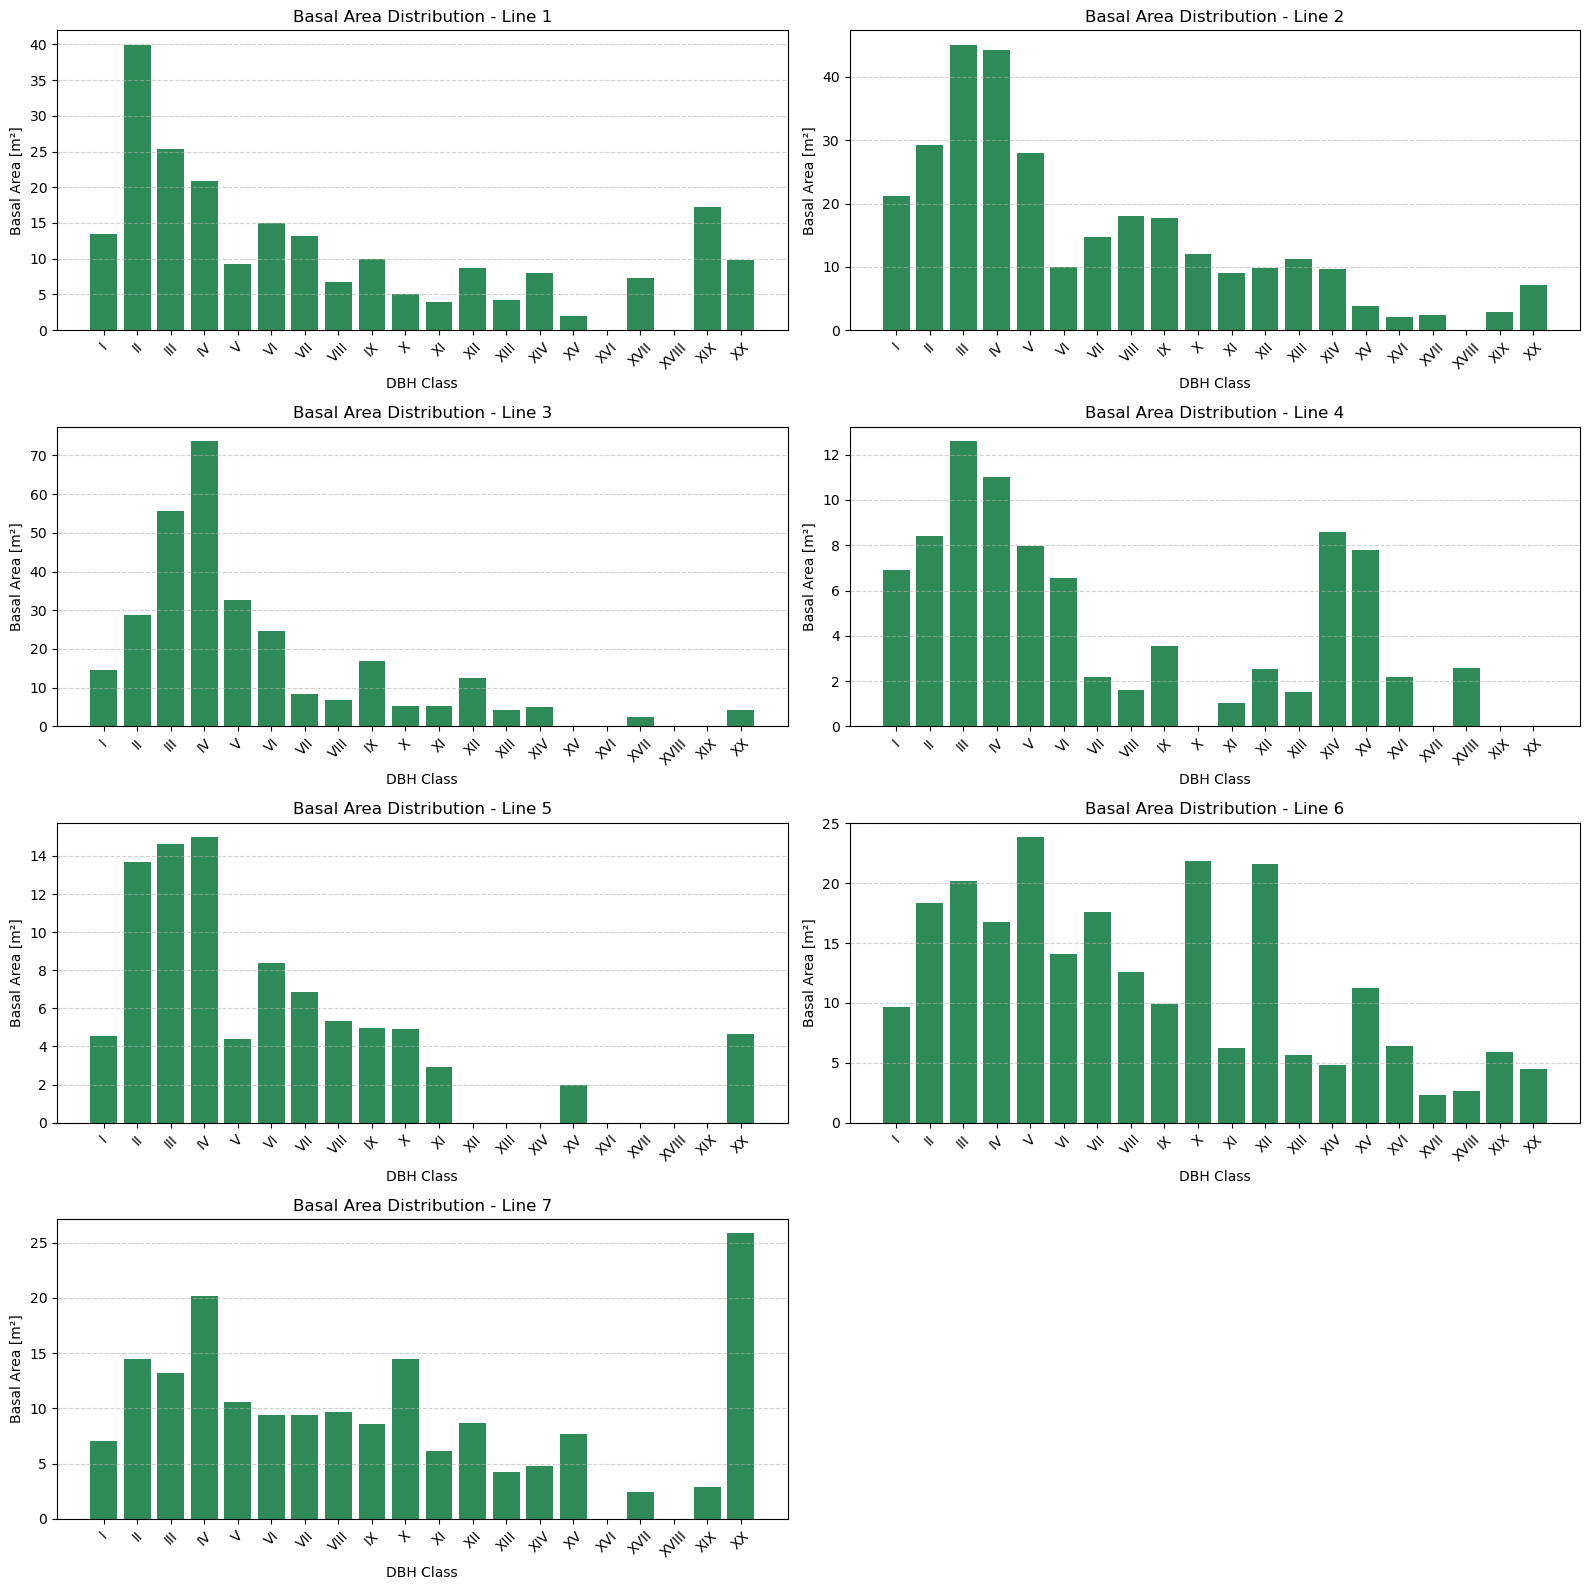

In [44]:
# Create a 4x2 matrix of subplots for Basal Area by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().sort_index()
    
    axes[i].bar(range(len(basal_area_by_class)), basal_area_by_class.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area [m²]')
    axes[i].set_title(f'Basal Area Distribution - Line {line_num}')
    axes[i].set_xticks(range(len(basal_area_by_class)))
    axes[i].set_xticklabels(basal_area_by_class.index, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_14052\4112469728.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\4112469728.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().reindex(dbh_categories, fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\4112469728.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retai

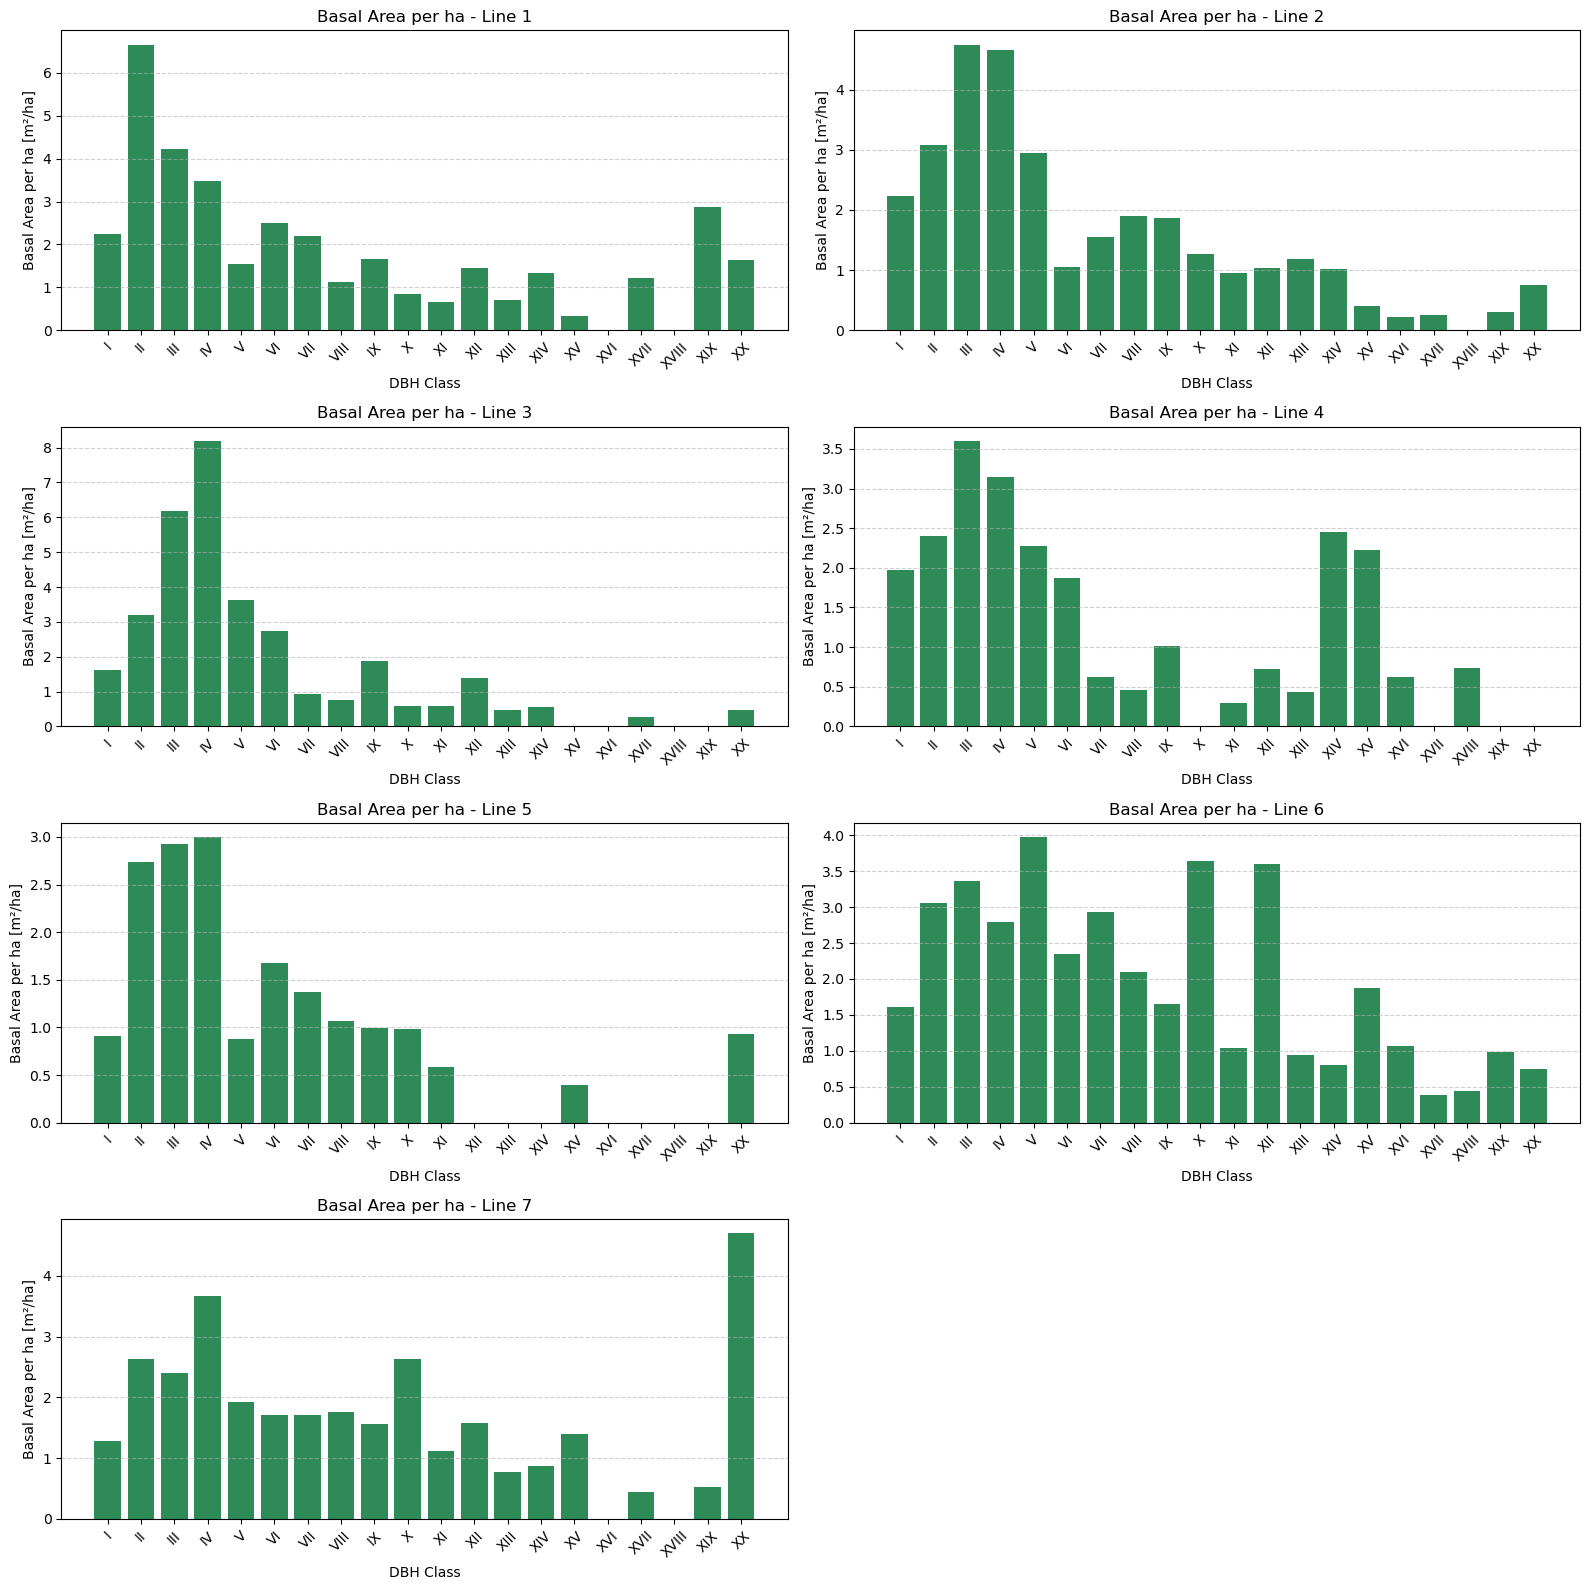

In [45]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().reindex(dbh_categories, fill_value=0)

    # Compute per-hectare basal area (handle missing/zero area)
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = basal_area_by_class / area
    else:
        ba_per_ha = pd.Series([np.nan] * len(basal_area_by_class), index=basal_area_by_class.index)

    axes[i].bar(range(len(ba_per_ha)), ba_per_ha.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area per ha [m²/ha]')
    axes[i].set_title(f'Basal Area per ha - Line {line_num}')
    axes[i].set_xticks(range(len(ba_per_ha)))
    axes[i].set_xticklabels(ba_per_ha.index, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()


In [46]:
# Sum basal area by line and only for the two target species, then convert to per-hectare using line_area_ha
basal_area_sum = (
    df.groupby(['Line Number'])['Basal area [m2]']
      .sum()
)
      
# Convert to per-hectare
basal_area_ha_by_line = basal_area_sum.div(line_area_ha, axis=0)

# Display the result
print('Basal area (m²/ha) by Line and Species:')
display(basal_area_ha_by_line)

Basal area (m²/ha) by Line and Species:


C:\Users\migue\AppData\Local\Temp\ipykernel_14052\2516773843.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Line Number'])['Basal area [m2]']


Line Number
1    36.617425
2    31.410743
3    33.397339
4    24.859179
5    18.447296
6    39.362195
7    32.690184
dtype: float64

C:\Users\migue\AppData\Local\Temp\ipykernel_14052\2607055071.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_sum = df.groupby('Line Number')['Basal area [m2]'].sum()


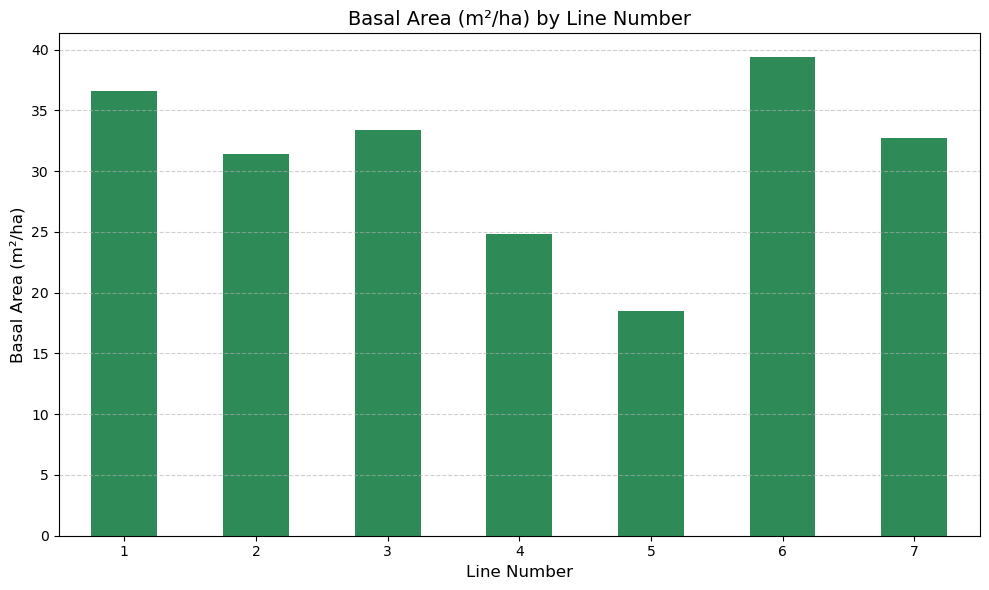

In [47]:
# 2. Sum basal area by line
basal_area_sum = df.groupby('Line Number')['Basal area [m2]'].sum()

# 3. Convert to per-hectare
basal_area_ha_by_line = basal_area_sum.div(line_area_ha, axis=0)

# --- CHARTING SECTION ---

# 4. Clean the data for plotting: Convert index to integer and sort
# We use .dropna() in case some lines had no target species
plot_data = basal_area_ha_by_line.dropna().sort_index()
plot_data.index = plot_data.index.astype(int)

# 5. Create the Bar Chart
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color='#2E8B57')

# Formatting labels and titles
plt.title('Basal Area (m²/ha) by Line Number', fontsize=14)
plt.xlabel('Line Number', fontsize=12)
plt.ylabel('Basal Area (m²/ha)', fontsize=12)
plt.xticks(rotation=0)  # Keeps the line numbers horizontal for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('basal_area_by_line.png')
plt.show()

### 4.3 Log volume

C:\Users\migue\AppData\Local\Temp\ipykernel_14052\1896432762.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\1896432762.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\1896432762.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain c

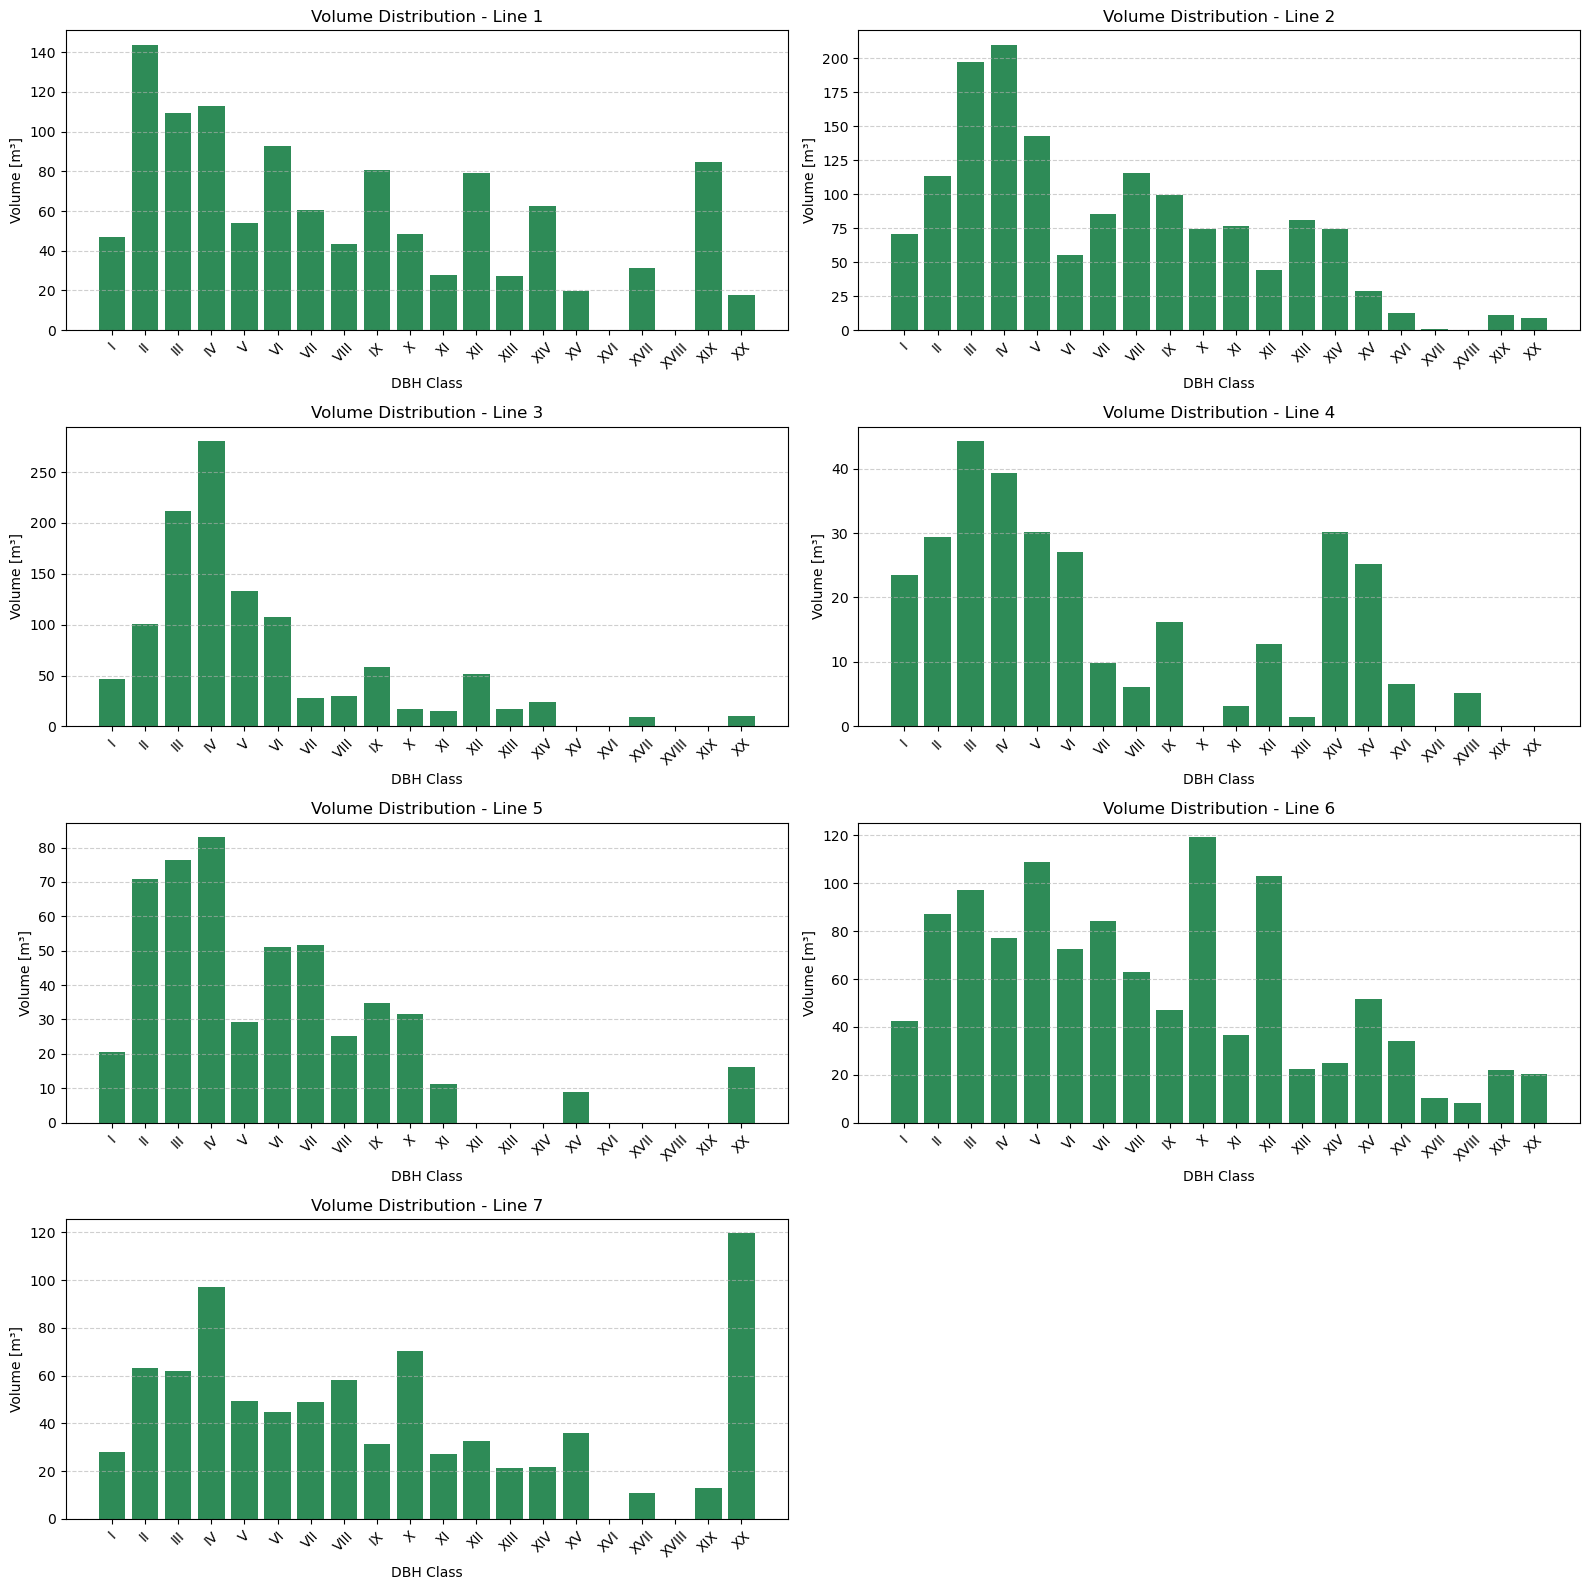

In [48]:
# Create a 4x2 matrix of subplots for Volume by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().sort_index()
    
    axes[i].bar(range(len(basal_area_by_class)), basal_area_by_class.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume [m³]')
    axes[i].set_title(f'Volume Distribution - Line {line_num}')
    axes[i].set_xticks(range(len(basal_area_by_class)))
    axes[i].set_xticklabels(basal_area_by_class.index, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_14052\1418930226.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\1418930226.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().reindex(dbh_categories, fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_14052\1418930226.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain cu

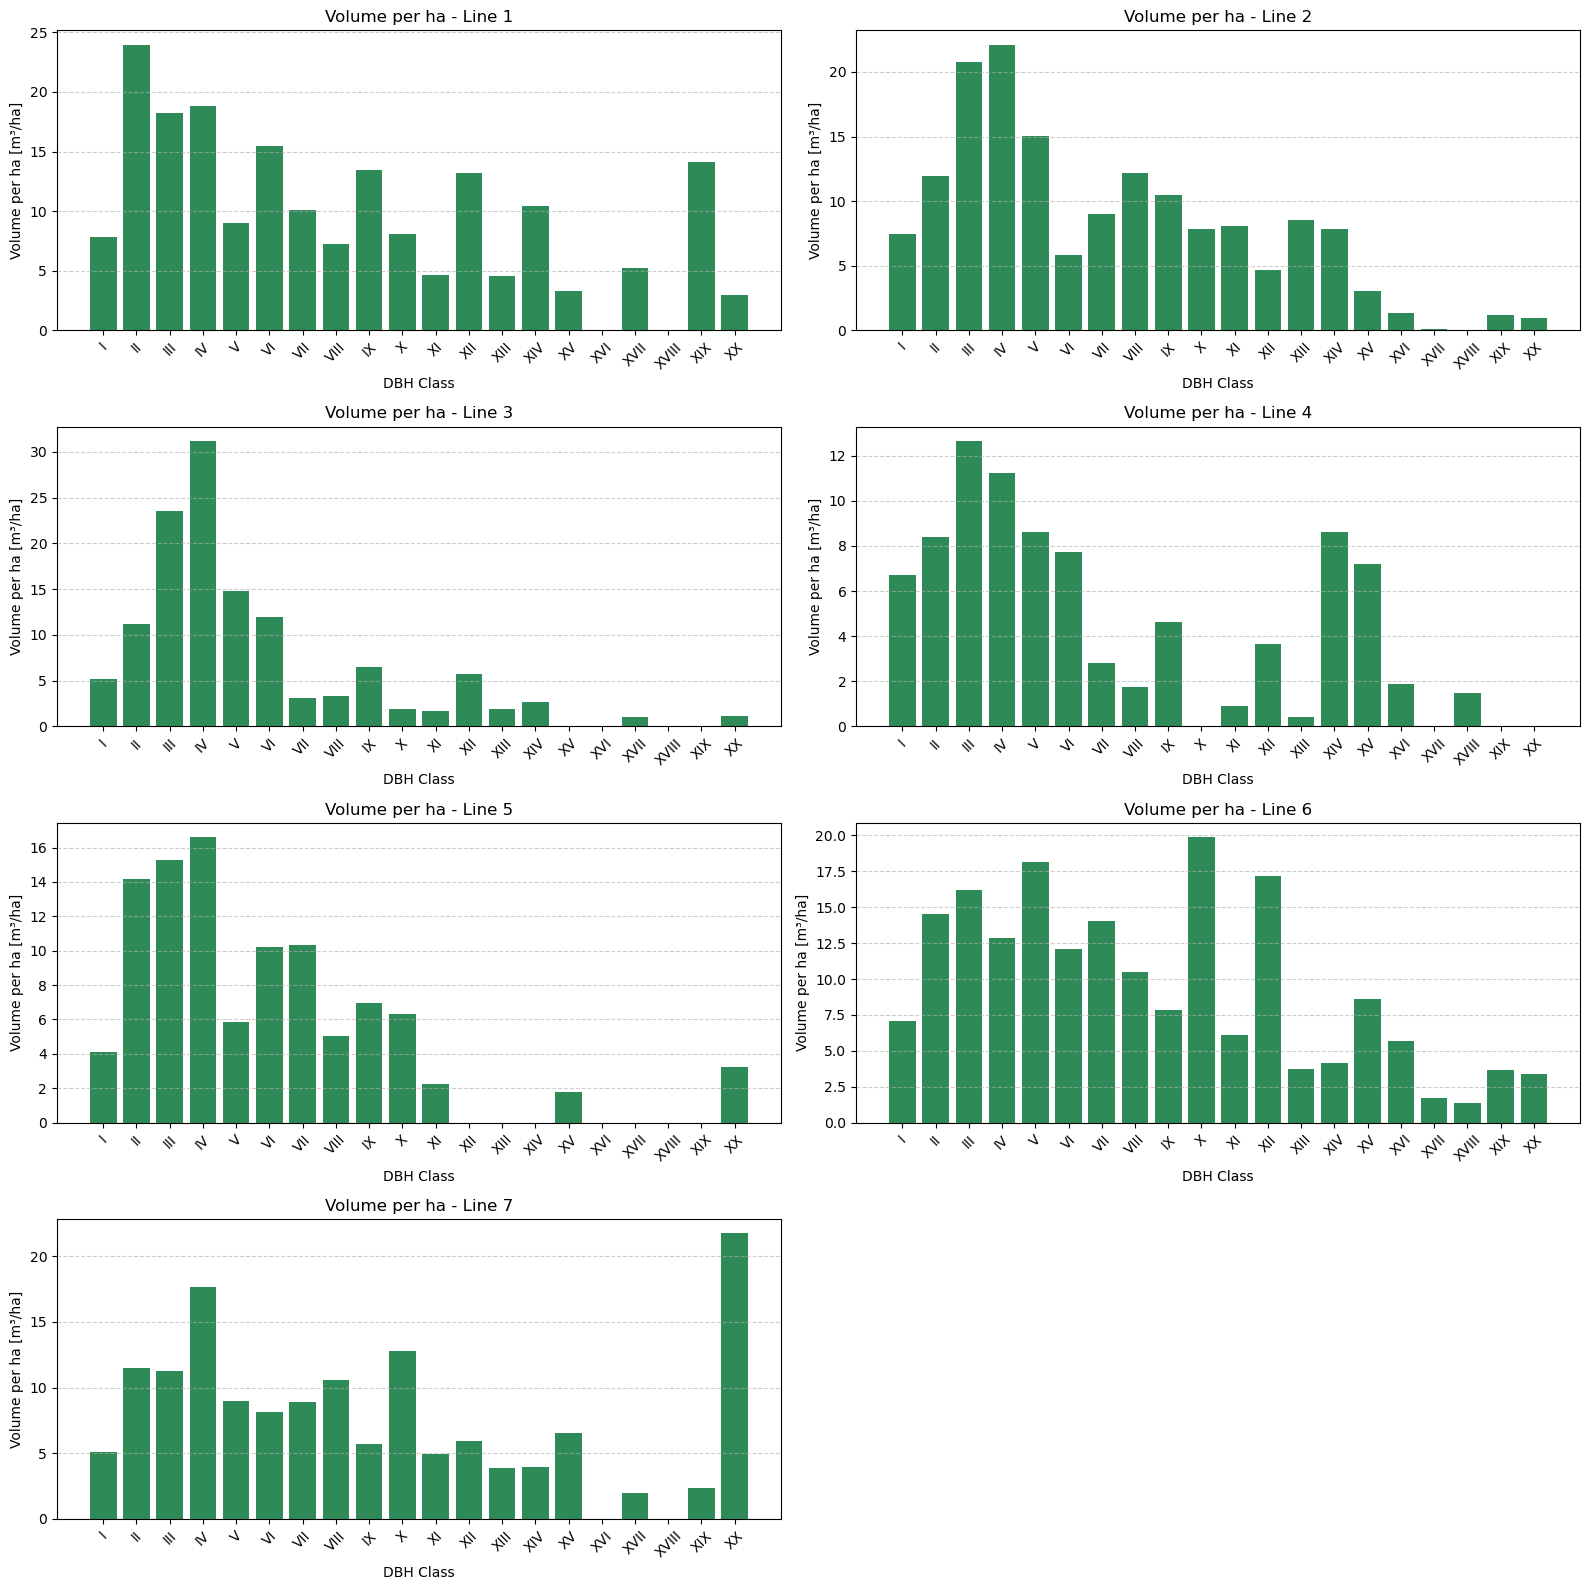

In [49]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().reindex(dbh_categories, fill_value=0)

    # Compute per-hectare basal area (handle missing/zero area)
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = basal_area_by_class / area
    else:
        ba_per_ha = pd.Series([np.nan] * len(basal_area_by_class), index=basal_area_by_class.index)

    axes[i].bar(range(len(ba_per_ha)), ba_per_ha.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume per ha [m³/ha]')
    axes[i].set_title(f'Volume per ha - Line {line_num}')
    axes[i].set_xticks(range(len(ba_per_ha)))
    axes[i].set_xticklabels(ba_per_ha.index, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\migue\AppData\Local\Temp\ipykernel_14052\2295983738.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_sum = df.groupby('Line Number')['Volume [m3]'].sum()


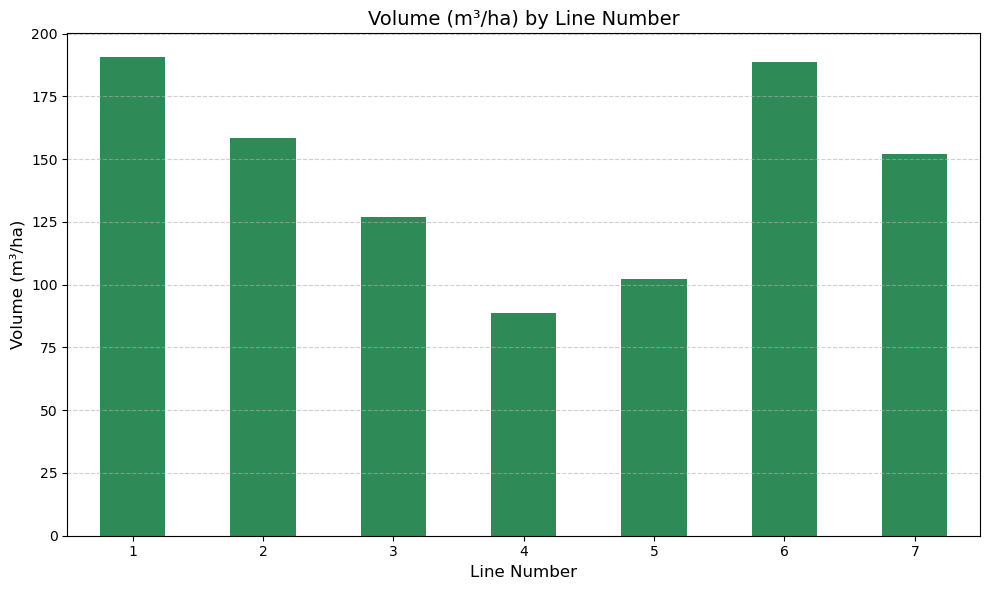

In [50]:
# 2. Sum volume by line
volume_sum = df.groupby('Line Number')['Volume [m3]'].sum()

# 3. Convert to per-hectare
volume_ha_by_line = volume_sum.div(line_area_ha, axis=0)

# --- CHARTING SECTION ---

# 4. Clean data: Convert index to integer, sort, and drop empty values
plot_data_vol = volume_ha_by_line.dropna().sort_index()
plot_data_vol.index = plot_data_vol.index.astype(int)

# 5. Create the Bar Chart
plt.figure(figsize=(10, 6))
plot_data_vol.plot(kind='bar', color='#2E8B57')

# Formatting labels and titles
plt.title('Volume (m³/ha) by Line Number', fontsize=14)
plt.xlabel('Line Number', fontsize=12)
plt.ylabel('Volume (m³/ha)', fontsize=12)
plt.xticks(rotation=0)  
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
